# Experimento C1: entorno estocástico con mayor demanda de viajes

### Carga de librerías

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

import entorno
import agentes
import train

### Parámetros del entorno

In [ ]:
TAMANOS = {
    'n_estaciones': 4,
    'anclas_por_est': 10,
    'bicis_por_est': 5,    # Estado inicial
    'bicis_por_accion': 2  # Bicis movidas por el agente en c/ accion
}
COSTOS = {
    'accion': 1,
    'accion_invalida': 10,
    'est_vacia': 1,
    'est_llena': 1,
}
TIEMPOS = {
    'viaje': 10,
    'accion': 5,
    'episodio': 8*60,
    'estado': 1,
    'update': 999
}

TRAIN_PARAMS = {
    'alpha_init': 0.1,
    'alpha_step': 1,
    'alpha_end':  0.1,

    'eps_init': 0.7,
    'eps_step': 1,
    'eps_end':  0.7
}

### Entrenar agentes con $p = 0,3$

In [4]:
PROBS = {
    'origen': 4*[0.3],
    'destino': np.array(4*[4*[0.25]])
}

random.seed(10)

env = entorno.Entorno(TAMANOS, COSTOS, TIEMPOS, PROBS)

agente_Q = agentes.QLearningAgent(action_size=env.action_space.n, alpha=TRAIN_PARAMS['alpha_init'], epsilon=TRAIN_PARAMS['eps_init'])
_, metricas_train_test, counters_train_test, best_qtable = train.train_test(env, agente_Q, params=TRAIN_PARAMS, N=10**5, keep_best=True, verbose=False)

Entrenamiento finalizado en 28.4 minutos.


In [6]:
random.seed(777)

env = entorno.Entorno(TAMANOS, COSTOS, TIEMPOS, PROBS)

print("=== Agente Nulo ===")
agente_N = agentes.NullAgent()
_, _, _, _ = train.train(env, agente_N, params=TRAIN_PARAMS, N=10**3)

print("=== Agente Aleatorio ===")
agente_R = agentes.RandomAgent(action_size=env.action_space.n)
_, _, _, _ = train.train(env, agente_R, params=TRAIN_PARAMS, N=10**3)

print("=== Agente Heurístico v1 ===")
agente_H = agentes.HeuristicAgent(action_size=env.action_space.n)
_, _, _, _ = train.train(env, agente_H, params=TRAIN_PARAMS, N=10**3)

print("=== Agente Q-learning ===")
_, metricas_test, counters_test, _ = train.test(env, agente_Q.q_table, N=10**3)

print("=== Agente Heurístico v2 ===")
agente_H2 = agentes.HeuristicAgent2(action_size=env.action_space.n)
_, _, _, _ = train.train(env, agente_H2, params=TRAIN_PARAMS, N=10**3)

=== Agente Nulo ===
Entrenamiento finalizado en 0.1 minutos.
# Insatisfechos: 103.3 ± 15.6 (22.0 ± 3.8%)
# Prolongados: 2.7 ± 2.9 (0.6 ± 0.6%)
Tiempo desbalanceo: 466.0 ± 55.8 (24.3 ± 2.9%)
Recompensa: -106.0 ± 16.9
=== Agente Aleatorio ===
Entrenamiento finalizado en 0.1 minutos.
# Insatisfechos: 119.9 ± 13.7 (26.2 ± 3.4%)
# Prolongados: 2.7 ± 2.5 (0.6 ± 0.6%)
Tiempo desbalanceo: 528.3 ± 42.4 (27.5 ± 2.2%)
Recompensa: -708.1 ± 100.8
=== Agente Heurístico v1 ===
Entrenamiento finalizado en 0.1 minutos.
# Insatisfechos: 89.5 ± 12.5 (18.4 ± 2.6%)
# Prolongados: 0.0 ± 0.1 (0.0 ± 0.0%)
Tiempo desbalanceo: 403.4 ± 36.9 (21.0 ± 1.9%)
Recompensa: -97.4 ± 13.6
=== Agente Q-learning ===
Entrenamiento finalizado en 0.1 minutos.
# Insatisfechos: 98.5 ± 12.5 (20.6 ± 2.9%)
# Prolongados: 0.6 ± 1.0 (0.1 ± 0.2%)
Tiempo desbalanceo: 442.3 ± 38.0 (23.0 ± 2.0%)
Recompensa: -133.0 ± 16.4
=== Agente Heurístico v2 ===
Entrenamiento finalizado en 0.1 minutos.
# Insatisfechos: 81.3 ± 11.3 (16.5 ± 2.3%)
# Pro

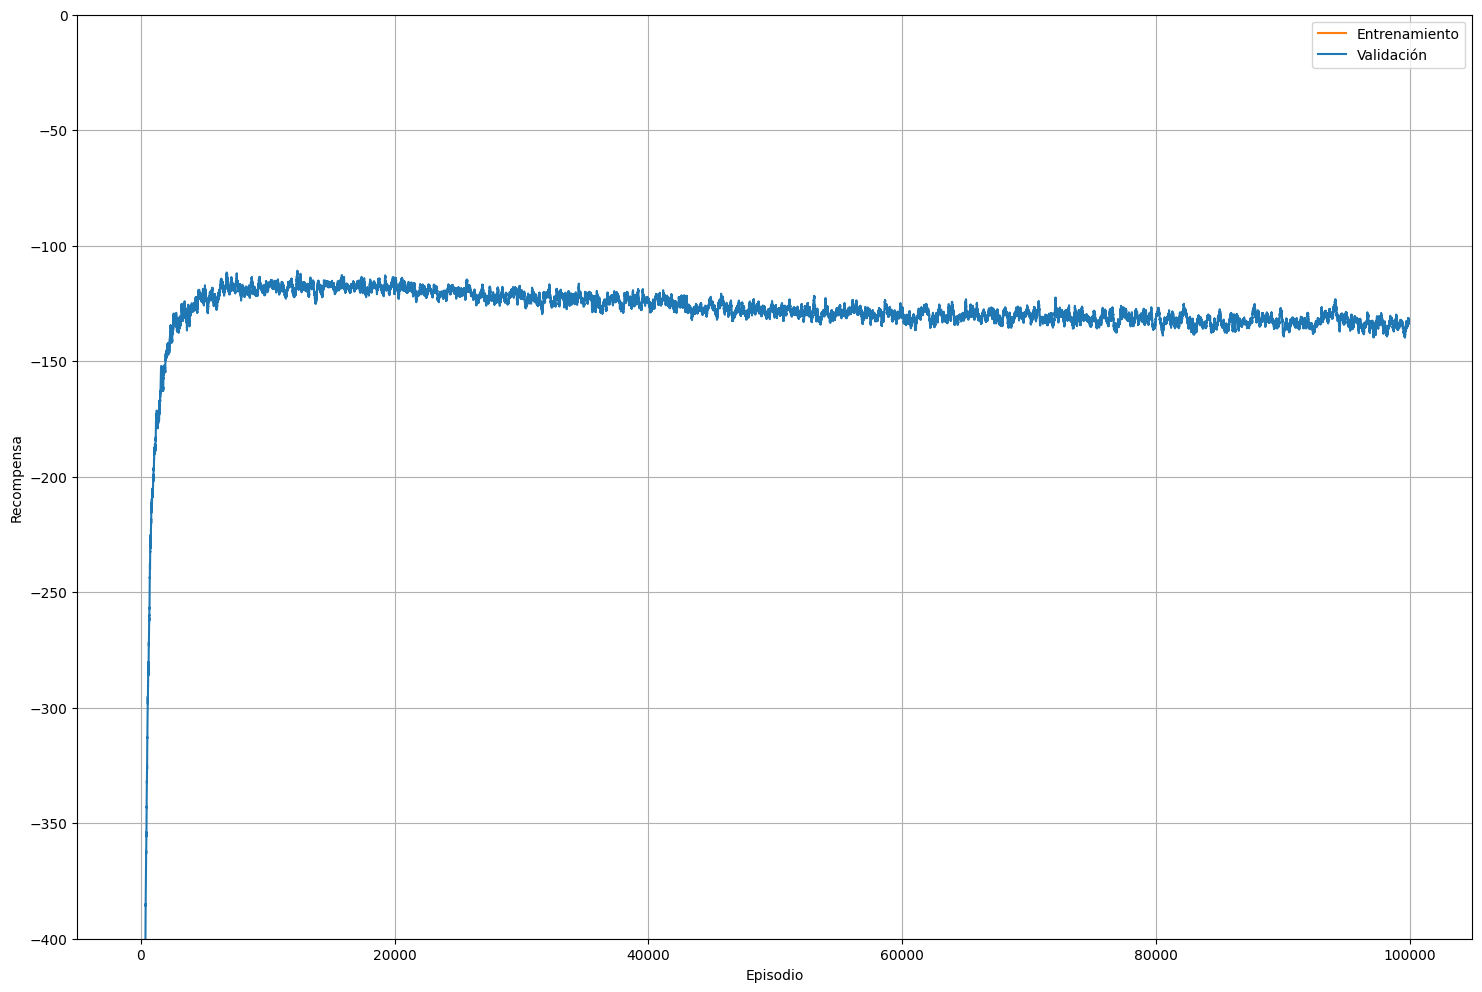

In [7]:
train.train_test_plot(metricas_train_test['rewards'])

### Entrenar agentes con $p = 0,5$

In [8]:
PROBS = {
    'origen': 4*[0.5],
    'destino': np.array(4*[4*[0.25]])
}

random.seed(10)

env = entorno.Entorno(TAMANOS, COSTOS, TIEMPOS, PROBS)

agente_Q = agentes.QLearningAgent(action_size=env.action_space.n, alpha=TRAIN_PARAMS['alpha_init'], epsilon=TRAIN_PARAMS['eps_init'])
_, metricas_train_test, counters_train_test, best_qtable = train.train_test(env, agente_Q, params=TRAIN_PARAMS, N=10**5, keep_best=True, verbose=False)

Entrenamiento finalizado en 41.1 minutos.


In [9]:
random.seed(999)

env = entorno.Entorno(TAMANOS, COSTOS, TIEMPOS, PROBS)

print("=== Agente Nulo ===")
agente_N = agentes.NullAgent()
_, _, _, _ = train.train(env, agente_N, params=TRAIN_PARAMS, N=10**3)

print("=== Agente Aleatorio ===")
agente_R = agentes.RandomAgent(action_size=env.action_space.n)
_, _, _, _ = train.train(env, agente_R, params=TRAIN_PARAMS, N=10**3)

print("=== Agente Heurístico v1 ===")
agente_H = agentes.HeuristicAgent(action_size=env.action_space.n)
_, _, _, _ = train.train(env, agente_H, params=TRAIN_PARAMS, N=10**3)

print("=== Agente Q-learning ===")
_, metricas_test, counters_test, _ = train.test(env, agente_Q.q_table, N=10**3)

print("=== Agente Heurístico v2 ===")
agente_H2 = agentes.HeuristicAgent2(action_size=env.action_space.n)
_, _, _, _ = train.train(env, agente_H2, params=TRAIN_PARAMS, N=10**3)

=== Agente Nulo ===
Entrenamiento finalizado en 0.2 minutos.
# Insatisfechos: 263.4 ± 17.9 (37.9 ± 2.9%)
# Prolongados: 0.3 ± 0.8 (0.0 ± 0.1%)
Tiempo desbalanceo: 785.3 ± 34.0 (40.9 ± 1.8%)
Recompensa: -263.7 ± 18.1
=== Agente Aleatorio ===
Entrenamiento finalizado en 0.2 minutos.
# Insatisfechos: 290.5 ± 17.2 (43.2 ± 2.8%)
# Prolongados: 0.1 ± 0.5 (0.0 ± 0.1%)
Tiempo desbalanceo: 853.2 ± 30.0 (44.4 ± 1.6%)
Recompensa: -1400.5 ± 155.8
=== Agente Heurístico v1 ===
Entrenamiento finalizado en 0.2 minutos.
# Insatisfechos: 259.9 ± 16.9 (37.1 ± 2.6%)
# Prolongados: 0.0 ± 0.1 (0.0 ± 0.0%)
Tiempo desbalanceo: 777.6 ± 31.7 (40.5 ± 1.7%)
Recompensa: -261.9 ± 17.4
=== Agente Q-learning ===
Entrenamiento finalizado en 0.2 minutos.
# Insatisfechos: 284.2 ± 17.0 (41.9 ± 2.9%)
# Prolongados: 0.2 ± 0.7 (0.0 ± 0.1%)
Tiempo desbalanceo: 835.7 ± 31.5 (43.5 ± 1.6%)
Recompensa: -347.5 ± 31.0
=== Agente Heurístico v2 ===
Entrenamiento finalizado en 0.2 minutos.
# Insatisfechos: 257.0 ± 16.0 (36.6 ± 2.4%)
